### [ 연속 영역 분할 2 : 레이블링 (Connected Components Labeling)] <hr>
- 원리 : 서로 연결된 흰색 영역마다 서로 다른 번호를 부여
- 조건 : 이진화 이미지 데이터 사용

In [5]:
import cv2
import numpy as np
import sys
import matplotlib.pyplot as plt
sys.path.append('..')
from cv_utils import *

- [1] 임의 픽셀로 이진 이미지 만들기

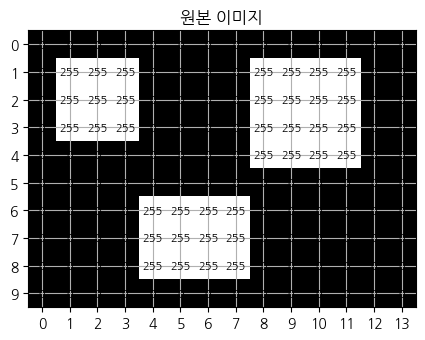

In [6]:
# 3개의 흰색 픽셀 영역 생성
image = np.zeros((10, 14), dtype=np.uint8)
image[1:4, 1:4] =255
image[1:5, 8:12] =255
image[6:9, 4:8] =255

printDistance(image, image, '원본 이미지')

- [2] 연결 요소 레이블링

In [7]:
# => 라벨링 진행
# 라벨링 후 통계 정보까지 반환 받음
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats( image, connectivity=8)

# 정보 출력
print("배경을 포함한 전체 레이블 수:, num_labels")
print("실제 객체 수:", num_labels - 1)
print("\n레이블 행렬")
print(labels)

print("\n레이블 행렬")
print(stats)

print("\n레이블 행렬")
print(centroids)

배경을 포함한 전체 레이블 수:, num_labels
실제 객체 수: 3

레이블 행렬
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0 0 2 2 2 2 0 0]
 [0 1 1 1 0 0 0 0 2 2 2 2 0 0]
 [0 1 1 1 0 0 0 0 2 2 2 2 0 0]
 [0 0 0 0 0 0 0 0 2 2 2 2 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 3 3 3 3 0 0 0 0 0 0]
 [0 0 0 0 3 3 3 3 0 0 0 0 0 0]
 [0 0 0 0 3 3 3 3 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

레이블 행렬
[[  0   0  14  10 103]
 [  1   1   3   3   9]
 [  8   1   4   4  16]
 [  4   6   4   3  12]]

레이블 행렬
[[6.54368932 4.73786408]
 [2.         2.        ]
 [9.5        2.5       ]
 [5.5        7.        ]]


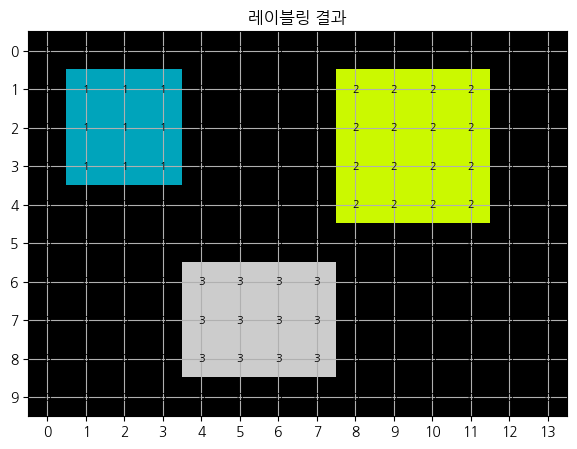

In [8]:
## => 라벨링 결과 시각화
# printDistance(labels, labels, "레이블링 결과", "nipy_spectral")
plt.figure(figsize=(8, 5))
plt.imshow(labels, cmap="nipy_spectral")
for y in range(labels.shape[0]):
    for x in range(labels.shape[1]):
        plt.text(x, y, str(labels[y, x]), ha="center", va="center", fontsize=8)
plt.title("레이블링 결과")
plt.xticks(range(labels.shape[1]))
plt.yticks(range(labels.shape[0]))
plt.grid()
plt.show()

In [9]:
for label in range(1, num_labels):
    x = stats[label, cv2.CC_STAT_LEFT]
    y = stats[label, cv2.CC_STAT_TOP]
    w = stats[label, cv2.CC_STAT_WIDTH]
    h = stats[label, cv2.CC_STAT_HEIGHT]
    a = stats[label, cv2.CC_STAT_AREA]

    center_x, center_y = centroids[label]

    print(f'{label}')
    print(f'{x},{y}')
    print(f'{w},{h}')
    print(f'{a}')
    print(f'{center_x:.2f}, {center_y:.2f}')

1
1,1
3,3
9
2.00, 2.00
2
8,1
4,4
16
9.50, 2.50
3
4,6
4,3
12
5.50, 7.00


## 핵심 정리
레이블링은 서로 연결된 객체를 구별하고 개수를 셀 때 사용합니다.

활용 예:
- 객체 개수 세기
- 가장 큰 객체 선택
- 작은 노이즈 제거 
- 객체의 중심점과 면적 계산